In [1]:
import os
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import plotly.io as pio
from urllib.parse import quote_plus

In [2]:
# Load the environment variables from a .env file
load_dotenv()

# Load the database connection settings.
password = quote_plus(os.environ.get("PASSWORD"))
host = os.environ.get("POOLER_HOST")

db_url = f"postgresql://postgres.frirgmurifmzfqicinqd:{password}@{host}:6543/postgres"
engine = create_engine(db_url)

In [3]:
#Define reusable query functions
def run_query(query):
    return pd.read_sql(query, engine)

### Basic data check

In [4]:
# test connection and query
test_df = run_query("""
	SELECT *
	FROM "ads-data"
	LIMIT 5;
""")

test_df



,created_at,date,platform,campaign_type,industry,country,impressions,clicks,CTR,CPC,ad_spend,conversions,CPA,revenue,ROAS
0,2026-09-16 11:22:53.603775+00:00,2024-01-21,Google Ads,Search,Fintech,UAE,59886,2113,0.0353,1.26,2662.38,159,16.74,4803.43,1.80
1,2026-09-16 11:22:53.603775+00:00,2024-01-22,TikTok Ads,Search,EdTech,UK,135608,5220,0.0385,1.18,6159.60,411,14.99,64126.70,10.41
2,2026-09-16 11:22:53.603775+00:00,2024-06-15,TikTok Ads,Video,Healthcare,USA,92313,5991,0.0649,0.85,5092.35,267,19.07,10489.10,2.06
3,2026-09-16 11:22:53.603775+00:00,2024-01-02,TikTok Ads,Shopping,SaaS,Germany,83953,5935,0.0707,1.32,7834.20,296,26.47,50505.10,6.45
4,2026-09-16 11:22:53.603775+00:00,2024-02-22,TikTok Ads,Search,Healthcare,UK,91807,4489,0.0489,1.93,8663.77,107,80.97,3369.53,0.39


In [5]:
# validate funnel logic
basic_df = run_query("""
    SELECT *
    FROM "ads-data"
    WHERE clicks > impressions
       OR conversions > clicks
       OR ad_spend < 0
       OR revenue < 0;
""")

### How does the advertising business look like overall?

In [6]:
# overall performance metrics
overall_df = run_query("""
    SELECT
        SUM(impressions) AS "Total Impressions",
        SUM(clicks) AS "Total Clicks",
        SUM(conversions) AS "Total Conversions",
        SUM(ad_spend) AS "Total Ad Spend",
        SUM(revenue) AS "Total Revenue",
        SUM(ad_spend) / NULLIF(SUM(clicks), 0) AS "CPC",
        SUM(ad_spend) / NULLIF(SUM(conversions), 0) AS "CPA",
        SUM(revenue) / NULLIF(SUM(ad_spend), 0) AS "ROAS"
    FROM "ads-data";
""")

# convert the result to a matrix of rows for each metric and one column for the value
overall_df = overall_df.melt(var_name='metric', value_name='value')
overall_df['value'] = overall_df['value'].round(2)

#rename the metric and value headers to be more descriptive
overall_df.columns = ['Metric', 'Value']

display(overall_df) 

,Metric,Value
0,Total Impressions,1.852542e+08
1,Total Clicks,7.132816e+06
2,Total Conversions,3.268120e+05
3,Total Ad Spend,1.110880e+07
4,Total Revenue,5.418330e+07
5,CPC,1.560000e+00
6,CPA,3.399000e+01
7,ROAS,4.880000e+00


In [7]:
# plot overall performance metrics: average CPC, CPA, ROAS, 
cols_plot = overall_df[overall_df['Metric'].isin(['CPC', 'CPA', 'ROAS'])]

fig = px.bar(cols_plot, x='Metric', y='Value', text='Value', title='Overall Performance Metrics')
fig.update_traces(texttemplate='%{text:.2s}', textposition='outside')
fig.update_layout(uniformtext_minsize=8, uniformtext_mode='hide')
fig.update_layout(title={'text': 'Overall Performance Metrics', 'x': 0.5, 'xanchor': 'center'},
                  xaxis_title='', 
                  yaxis_title='Metric Value', 
                  legend_title='Metric',
                  height=550, width=600)
fig.show()

In [8]:
# plot total impressions, clicks, conversions, ad spend, and revenue
cols_plot = overall_df[overall_df['Metric'].isin([
    'Total Impressions', 'Total Clicks', 'Total Conversions', 'Total Ad Spend', 'Total Revenue'])]
fig = px.bar(cols_plot, x='Metric', y='Value', text='Value', title='Total Performance Metrics')
fig.update_traces(texttemplate='%{text:.2s}', textposition='outside')
fig.update_layout(uniformtext_minsize=8, uniformtext_mode='hide')
fig.update_layout(title={'text': 'Total Performance Metrics', 'x': 0.5, 'xanchor': 'center'},
                  xaxis_title='', 
                  yaxis_title='Metric Value', 
                  legend_title='Metric',
                  height=550, width=700)
fig.show()


### Platform performance

### How does performance differ by advertising platform?

In [9]:
# platform performance metrics
platform_df = run_query("""
    SELECT
        platform,
        SUM(impressions) AS "Total Impressions",
        SUM(clicks) AS "Total Clicks",
        SUM(conversions) AS "Total Conversions",
        SUM(ad_spend) AS "Total Ad Spend",
        SUM(revenue) AS "Total Revenue",
        
        ROUND(
            (SUM(clicks)::numeric  / NULLIF(SUM(impressions), 0)), 4
        ) AS "CTR",
        
        ROUND(
            (SUM(ad_spend)::numeric  / NULLIF(SUM(clicks), 0)), 2
        ) AS "CPC",
        
        ROUND(
            (SUM(ad_spend)::numeric  / NULLIF(SUM(conversions), 0)), 2
        ) AS "CPA",

        ROUND(
            (SUM(conversions)::numeric / NULLIF(SUM(clicks), 0)), 4) AS "Conversion Rate",

        SUM(revenue)/ NULLIF(SUM(ad_spend), 0) AS "ROAS"
    
    FROM "ads-data"
    GROUP BY platform;
""")

display(platform_df)

,platform,Total Impressions,Total Clicks,Total Conversions,Total Ad Spend,Total Revenue,CTR,CPC,CPA,Conversion Rate,ROAS
0,Meta Ads,64403494,1596736,73262,2106060.0,11926100.0,0.0248,1.32,28.75,0.0459,5.66272
1,TikTok Ads,47049590,2599931,122452,2653420.0,20223500.0,0.0553,1.02,21.67,0.0471,7.62170
2,Google Ads,73801150,2936149,131098,6349270.0,22033800.0,0.0398,2.16,48.43,0.0446,3.47028


In [10]:
# plot platform performance metrics: ctr, cpc, cpa, roas
platform_df_melted = platform_df.melt(id_vars='platform', var_name='metric', value_name='value')

cols_plot = platform_df_melted[platform_df_melted['metric'].isin(['CTR', 'CPC', 'CPA', 'ROAS'])]
fig = px.bar(cols_plot, x='platform', y='value', color='metric', barmode='group', text='value', title='Platform Performance Metrics')
fig.update_traces(texttemplate='%{text:.2s}', textposition='outside')
fig.update_layout(uniformtext_minsize=8, uniformtext_mode='hide')
fig.update_layout(title={'text': 'Platform Performance Metrics', 'x': 0.5, 'xanchor': 'center'},
                  xaxis_title='', 
                  yaxis_title='Metric Value', 
                  legend_title='Metric',
                  height=550, width=800)
fig.show()


**Insights:**

- CPA and CPC are lowest in TikTok Ads and highest in Google Ads
- ROAS is highest in TiTtok Ads and least in Google Ads

- TikTok is the best platform to invest in Ads because we pay less to acquire customers and generate more revenue for every dollar spent on advertising. With TikTok Ads, we are likely to buy efficient traffic and maximize Return on Ad Spend.

- Google Ads are expensive and have lower return on ad spend. 

## Campaign-type analysis

### Which campaign types generate different funnel economics?

In [11]:
by_campaign = run_query("""
    SELECT
        campaign_type,

        SUM(ad_spend) AS "Total Ad Spend",
        SUM(revenue) AS "Total Revenue",
        SUM(conversions) AS "Total Conversions",

        ROUND(
            (SUM(clicks)::numeric / NULLIF(SUM(impressions), 0)), 4) AS "CTR",
        
        ROUND(
            (SUM(ad_spend)::numeric / NULLIF(SUM(clicks), 0)), 2) AS "CPC",

        ROUND(
            SUM(conversions)::numeric / NULLIF(SUM(clicks), 0), 4) AS "Conversion Rate",

        ROUND(
            (SUM(ad_spend)::numeric / NULLIF(SUM(conversions), 0)), 2) AS "CPA",

        SUM(revenue) / NULLIF(SUM(ad_spend), 0) AS "ROAS"

    FROM "ads-data"

    GROUP BY campaign_type
    ORDER BY "ROAS" DESC;
""")

display(by_campaign)

,campaign_type,Total Ad Spend,Total Revenue,Total Conversions,CTR,CPC,Conversion Rate,CPA,ROAS
0,Search,2868010.0,15218500.0,90641,0.0399,1.51,0.0478,31.64,5.30628
1,Display,2644740.0,12798900.0,76869,0.0377,1.61,0.0469,34.41,4.83939
2,Video,2796460.0,13341300.0,79228,0.0379,1.54,0.0438,35.30,4.77077
3,Shopping,2799550.0,12824700.0,80074,0.0384,1.57,0.0449,34.96,4.58099


- Search Ads have the best crick through rate, highest conversion rate and return on every dollar spent, yet we pay less for every customer acquired compared to display, video, and shopping ads.  

### Which platform × campaign combinations to scale or investigate further?

In [12]:
# Platform × campaign interaction

by_platform_campaign = run_query("""
    SELECT
        platform,
        campaign_type,
        SUM(ad_spend) AS "Total Ad Spend",
        SUM(revenue) AS "Total Revenue",
        SUM(conversions) AS "Total Conversions",
        ROUND(
            (SUM(clicks)::numeric / NULLIF(SUM(impressions), 0)), 4) AS "CTR",
        ROUND(
            (SUM(ad_spend)::numeric / NULLIF(SUM(clicks), 0)), 2) AS "CPC",
        ROUND(
            SUM(conversions)::numeric / NULLIF(SUM(clicks), 0), 4) AS "Conversion Rate",
        ROUND(
            (SUM(ad_spend)::numeric / NULLIF(SUM(conversions), 0)), 2) AS "CPA",
        SUM(revenue) / NULLIF(SUM(ad_spend), 0) AS "ROAS"

    FROM "ads-data"
    GROUP BY platform, campaign_type
    ORDER BY "ROAS" DESC;
""")

display(by_platform_campaign)

,platform,campaign_type,Total Ad Spend,Total Revenue,Total Conversions,CTR,CPC,Conversion Rate,CPA,ROAS
0,TikTok Ads,Search,717502.0,5824810.0,35475,0.0573,0.99,0.0492,20.23,8.11818
1,TikTok Ads,Display,615957.0,4935070.0,28934,0.0540,1.06,0.0497,21.29,8.01204
2,TikTok Ads,Video,596830.0,4509110.0,27515,0.0540,0.98,0.0452,21.69,7.55511
3,TikTok Ads,Shopping,723130.0,4954550.0,30528,0.0554,1.05,0.0444,23.69,6.85154
4,Meta Ads,Display,547626.0,3188910.0,18634,0.0249,1.40,0.0475,29.39,5.82316
5,Meta Ads,Search,520979.0,3007010.0,18339,0.0251,1.34,0.0472,28.41,5.77183
6,Meta Ads,Shopping,501877.0,2778260.0,19127,0.0245,1.24,0.0471,26.24,5.53575
7,Meta Ads,Video,535580.0,2951860.0,17162,0.0247,1.31,0.0419,31.21,5.51153
8,Google Ads,Search,1629530.0,6386650.0,36827,0.0405,2.07,0.0467,44.25,3.91933
9,Google Ads,Video,1664050.0,5880290.0,34551,0.0398,2.10,0.0436,48.16,3.53372


In [13]:
# plot horizontal bar chart of by_platform_campaign data, with ROAS on the x-axis, campaign_type on the y-axis, and color by platform
fig = px.bar(by_platform_campaign, x='ROAS', y='campaign_type', color='platform', orientation='h', 
             title='ROAS by Platform and Campaign Type')  
fig.update_layout(yaxis={'categoryorder':'total ascending'}, yaxis_title='', 
                  xaxis_title='ROAS', legend_title='Platform',)
fig.show()  

- We can see that Google Ads are not just expensive but they yield the least return on every dollar spent across all campaign types.
- TikTok Ads perform well across all compaign types, yielding the highest return on every dollar spent compared to Google and Meta Ads. However, to maximine revenue return, **choose TikTok Search and TikTok Display** Ads because both campaigns are performing exceptionally well, with Search ads holding a slight edge in efficiency.


**TikTok Search vs Display Ads Performance Breakdown**

- **Traffic Acquisition:** Search successfully captures intent at a lower cost, securing a 7% cheaper CPC ($0.99 vs $1.06) and higher engagement (5.73% vs 5.40% CTR).

- **On-Site Conversion:** Display slightly outperforms Search on the landing page, converting at 4.97% vs 4.92%.

- **Bottom-Line Efficiency:** Because Search traffic costs less to acquire, it overcomes the slight CVR gap to deliver a 5% lower CPA ($20.23) and a stronger 8.20x ROAS.

- **Key Takeaway:** While Search holds a minor 2.4% edge in ROAS driven by a 5% lower CPA ($20.23 vs. $21.29), both networks are operating at near-identical, elite levels of profitability.

## Geographic analysis

### Geographic budget allocation: in which markets does the economics justify additional testing?

In [14]:
# Where are advertising economics strongest or weakest?

by_country = run_query("""
    SELECT
        country,
        SUM(ad_spend) AS "Total Ad Spend",
        SUM(revenue) AS "Total Revenue",
        SUM(conversions) AS "Total Conversions",
        ROUND(
            (SUM(clicks)::numeric / NULLIF(SUM(impressions), 0)), 4) AS "CTR",
        ROUND(
            (SUM(ad_spend)::numeric / NULLIF(SUM(clicks), 0)), 2) AS "CPC",
        ROUND(
            SUM(conversions)::numeric / NULLIF(SUM(clicks), 0), 4) AS "Conversion Rate",
        ROUND(
            (SUM(ad_spend)::numeric / NULLIF(SUM(conversions), 0)), 2) AS "CPA",
        SUM(revenue) / NULLIF(SUM(ad_spend), 0) AS "ROAS"
    
    FROM "ads-data"
    GROUP BY country
    ORDER BY "ROAS" DESC;
""")

display(by_country)

,country,Total Ad Spend,Total Revenue,Total Conversions,CTR,CPC,Conversion Rate,CPA,ROAS
0,India,1438740.0,7909610.0,46767,0.0383,1.42,0.0460,30.76,5.49758
1,Australia,1586260.0,7921850.0,45869,0.0404,1.65,0.0477,34.58,4.99403
2,Germany,1551060.0,7694840.0,44768,0.0381,1.56,0.0450,34.65,4.96101
3,UK,1547150.0,7659550.0,46842,0.0374,1.54,0.0465,33.03,4.95073
4,UAE,1614680.0,7939600.0,48345,0.0394,1.53,0.0458,33.40,4.91714
5,Canada,1643260.0,7867320.0,46243,0.0378,1.59,0.0447,35.54,4.78763
6,USA,1727590.0,7190580.0,47978,0.0385,1.62,0.0451,36.01,4.16221


- In USA, we pay more to acquire a customer yet we get the least return on ad spend. We spent 1.73M dollars and generated 7.19M dollars, only 4.2x compared to 5.5x we get from India.  
- India is the most efficient market yielding a marginally better 5.5x ROAS more cost-effectively ($30.76 CPA) followed closely by Australia (4.99x ROAS), Germany (4.96x ROAS), UK (4.95x ROAS), and UAE (4.92x ROAS). While these Markets are generating near-identical return on every dollar ad spend;

    * **India is The Efficiency Leader:** India runs laps around the other countries in terms of pure efficiency. It has the lowest CPA ($30.76) and the highest ROAS (5.50x), largely because it boasts the cheapest traffic cost ($1.42 CPC).

    * **UAE & USA are The Volume Leaders:** UAE generated the most total conversions (48,345) and the highest total revenue ($7.94M). USA generated the second-highest conversion volume (47,978) but did so at the worst efficiency (4.16x ROAS, $36.01 CPA) because of high traffic costs.

**Key Takeaway**

- Our global ad spend shows a distinct tradeoff between market efficiency and volume. India is our clear efficiency champion, delivering an elite 5.50x ROAS and the lowest acquisition cost ($30.76 CPA). 
- However, to drive maximum top-line scale, we rely on markets like the UAE and USA. The UAE successfully traded a slightly higher CPA ($33.40) to capture our highest volume of conversions (48,345) and total revenue ($7.94M). - Conversely, the USA presents our biggest optimization risk: while it successfully drives high volume (47,978 conversions), its expensive market competition pushed ROAS down to a baseline 4.16x.

### Is a country's performance driven by the country itself, or by the platforms being used there?

In [15]:
by_country_platform = run_query("""
    SELECT
        country,
        platform,
        SUM(ad_spend) AS "Total Ad Spend",
        SUM(revenue) AS "Total Revenue",
        SUM(conversions) AS "Total Conversions",
        ROUND(
            (SUM(clicks)::numeric / NULLIF(SUM(impressions), 0)), 4) AS "CTR",
        ROUND(
            (SUM(ad_spend)::numeric / NULLIF(SUM(clicks), 0)), 2) AS "CPC",
        ROUND(
            SUM(conversions)::numeric / NULLIF(SUM(clicks), 0), 4) AS "Conversion Rate",
        ROUND(
            (SUM(ad_spend)::numeric / NULLIF(SUM(conversions), 0)), 2) AS "CPA",
        SUM(revenue) / NULLIF(SUM(ad_spend), 0) AS "ROAS"
    
    FROM "ads-data"
    GROUP BY country, platform
    ORDER BY "ROAS" DESC;
""")

display(by_country_platform)

,country,platform,Total Ad Spend,Total Revenue,Total Conversions,CTR,CPC,Conversion Rate,CPA,ROAS
0,Australia,TikTok Ads,332803.0,2911980.0,17278,0.0556,0.95,0.0493,19.26,8.74988
1,Canada,TikTok Ads,393893.0,3355080.0,19305,0.0555,0.98,0.0480,20.40,8.51773
2,India,TikTok Ads,455189.0,3548600.0,21186,0.0568,1.03,0.0479,21.49,7.79590
3,UK,TikTok Ads,361477.0,2751470.0,17039,0.0522,1.06,0.0498,21.21,7.61175
4,Germany,TikTok Ads,358587.0,2546200.0,15451,0.0556,1.01,0.0436,23.21,7.10065
5,UAE,TikTok Ads,385036.0,2717350.0,17760,0.0566,1.05,0.0483,21.68,7.05740
6,Germany,Meta Ads,321998.0,2111660.0,11254,0.0243,1.35,0.0471,28.61,6.55797
7,USA,TikTok Ads,366433.0,2392840.0,14433,0.0542,1.08,0.0424,25.39,6.53009
8,Australia,Meta Ads,210486.0,1372580.0,7677,0.0253,1.29,0.0472,27.42,6.52104
9,UAE,Meta Ads,245342.0,1478190.0,9727,0.0254,1.17,0.0463,25.22,6.02501


## Industry analysis

### Which industries deserve more acquisition investment?

In [16]:
# Industry analysis
by_industry = run_query("""
    SELECT
        industry,
        SUM(ad_spend) AS "Total Ad Spend",
        SUM(revenue) AS "Total Revenue",
        SUM(conversions) AS "Total Conversions",
        ROUND(
            (SUM(clicks)::numeric / NULLIF(SUM(impressions), 0)), 4) AS "CTR",
        ROUND(
            (SUM(ad_spend)::numeric / NULLIF(SUM(clicks), 0)), 2) AS "CPC",
        ROUND(
            SUM(conversions)::numeric / NULLIF(SUM(clicks), 0), 4) AS "Conversion Rate",
        ROUND(
            (SUM(ad_spend)::numeric / NULLIF(SUM(conversions), 0)), 2) AS "CPA",
        SUM(revenue) / NULLIF(SUM(ad_spend), 0) AS "ROAS"
    FROM "ads-data"
    GROUP BY industry
    ORDER BY "ROAS" DESC;
""")

display(by_industry)

,industry,Total Ad Spend,Total Revenue,Total Conversions,CTR,CPC,Conversion Rate,CPA,ROAS
0,SaaS,2357560.0,11892000.0,71261,0.0408,1.52,0.0459,33.08,5.04419
1,EdTech,2296980.0,11549900.0,67257,0.0377,1.53,0.0448,34.15,5.02832
2,E-commerce,1923990.0,9637280.0,57486,0.0379,1.50,0.0449,33.47,5.00902
3,Healthcare,2258680.0,10930800.0,65687,0.0379,1.63,0.0474,34.39,4.83946
4,Fintech,2271540.0,10173300.0,65121,0.0382,1.61,0.0461,34.88,4.47860


In [17]:
# industry × platform interaction
by_industry_platform = run_query("""
    SELECT
        industry,
        platform,
        SUM(ad_spend) AS "Total Ad Spend",
        SUM(revenue) AS "Total Revenue",
        SUM(conversions) AS "Total Conversions",
        ROUND(
            (SUM(clicks)::numeric / NULLIF(SUM(impressions), 0)), 4) AS "CTR",
        ROUND(
            (SUM(ad_spend)::numeric / NULLIF(SUM(clicks), 0)), 2) AS "CPC",
        ROUND(
            SUM(conversions)::numeric / NULLIF(SUM(clicks), 0), 4) AS "Conversion Rate",
        ROUND(
            (SUM(ad_spend)::numeric / NULLIF(SUM(conversions), 0)), 2) AS "CPA",
        SUM(revenue) / NULLIF(SUM(ad_spend), 0) AS "ROAS"
    FROM "ads-data"
    GROUP BY industry, platform
    ORDER BY "ROAS" DESC;
""")

display(by_industry_platform)

,industry,platform,Total Ad Spend,Total Revenue,Total Conversions,CTR,CPC,Conversion Rate,CPA,ROAS
0,E-commerce,TikTok Ads,428276.0,3581730.0,20628,0.0535,0.98,0.0473,20.76,8.36312
1,SaaS,TikTok Ads,647472.0,5345540.0,31646,0.0566,0.97,0.0475,20.46,8.25601
2,Healthcare,TikTok Ads,520393.0,3996480.0,24155,0.0551,1.07,0.0497,21.54,7.67973
3,EdTech,TikTok Ads,575030.0,4223810.0,25190,0.0536,1.05,0.0459,22.83,7.34537
4,Healthcare,Meta Ads,445677.0,2901100.0,17003,0.0251,1.30,0.0496,26.21,6.50942
5,Fintech,TikTok Ads,482247.0,3075990.0,20833,0.0572,1.04,0.0451,23.15,6.37846
6,EdTech,Meta Ads,441251.0,2745050.0,15513,0.0246,1.27,0.0446,28.44,6.22107
7,SaaS,Meta Ads,382760.0,2181960.0,13104,0.0253,1.41,0.0484,29.21,5.70059
8,E-commerce,Meta Ads,409121.0,2034150.0,13704,0.0248,1.25,0.0418,29.85,4.97201
9,Fintech,Meta Ads,427253.0,2063790.0,13938,0.0242,1.39,0.0453,30.65,4.83037


## Country × Industry × Platform × Campaign Type

In [18]:
# Country × Industry × Platform × Campaign Type
country_industry_platform_campaign = run_query("""
    SELECT
        country,
        industry,
        platform,
        campaign_type,
        SUM(ad_spend) AS "Total Ad Spend",
        SUM(revenue) AS "Total Revenue",
        SUM(conversions) AS "Total Conversions",
        ROUND(
            (SUM(clicks)::numeric / NULLIF(SUM(impressions), 0)), 4) AS "CTR",
        ROUND(
            (SUM(ad_spend)::numeric / NULLIF(SUM(clicks), 0)), 2) AS "CPC",
        ROUND(
            SUM(conversions)::numeric / NULLIF(SUM(clicks), 0), 4) AS "Conversion Rate",
        ROUND(
            (SUM(ad_spend)::numeric / NULLIF(SUM(conversions), 0)), 2) AS "CPA",
        SUM(revenue) / NULLIF(SUM(ad_spend), 0) AS "ROAS"
    FROM "ads-data"
    GROUP BY country, industry, platform, campaign_type
    ORDER BY "ROAS" DESC;
""")

display(country_industry_platform_campaign.head(10))

,country,industry,platform,campaign_type,Total Ad Spend,Total Revenue,Total Conversions,CTR,CPC,Conversion Rate,CPA,ROAS
0,USA,SaaS,TikTok Ads,Video,9673.80,281710.0,1041,0.0528,0.65,0.0695,9.29,29.1209
1,UK,E-commerce,TikTok Ads,Display,1182.30,30312.3,167,0.0395,0.35,0.0494,7.08,25.6384
2,Australia,SaaS,TikTok Ads,Search,9072.64,228511.0,919,0.0697,0.42,0.0423,9.87,25.1868
3,Germany,E-commerce,TikTok Ads,Display,3404.92,79876.3,366,0.0497,0.59,0.0638,9.30,23.4591
4,Germany,E-commerce,TikTok Ads,Video,9296.19,204663.0,758,0.0542,0.78,0.0639,12.26,22.0158
5,UAE,EdTech,Meta Ads,Search,6470.86,132440.0,545,0.0308,0.65,0.0546,11.87,20.4672
6,Australia,EdTech,TikTok Ads,Search,14270.20,284974.0,1187,0.0484,0.69,0.0575,12.02,19.9699
7,Germany,E-commerce,TikTok Ads,Search,8692.41,170090.0,945,0.0483,0.60,0.0650,9.20,19.5677
8,Australia,E-commerce,TikTok Ads,Search,21646.40,420731.0,2054,0.0560,0.70,0.0663,10.54,19.4366
9,India,EdTech,Meta Ads,Shopping,4546.08,82096.8,335,0.0366,0.72,0.0531,13.57,18.0588


### statistical/business significance thresholds

Check whether those combinations have enough spend/observations

In [19]:
#statistical/business significance thresholds

stats_df = run_query("""
    WITH performance AS (
        SELECT
            country,
            industry,
            platform,
            campaign_type,
            COUNT(*) AS observations,
            SUM(ad_spend) AS spend,
            SUM(revenue) AS revenue,
            SUM(conversions) AS conversions
        FROM "ads-data"
        GROUP BY country, industry, platform, campaign_type
    )
    SELECT
        *,
        ROUND(spend::NUMERIC / NULLIF(conversions, 0), 2) AS cpa,
        ROUND(revenue::NUMERIC / NULLIF(spend::NUMERIC, 0), 2) AS roas
    FROM performance
    WHERE observations >= 10 AND spend >= 10000
    ORDER BY roas DESC;
""")

display(stats_df)

,country,industry,platform,campaign_type,observations,spend,revenue,conversions,cpa,roas
0,India,EdTech,TikTok Ads,Video,10,58952.2,517884.0,2630,22.42,8.78
1,USA,SaaS,Meta Ads,Display,11,35523.1,226355.0,1648,21.56,6.37
2,USA,E-commerce,Meta Ads,Search,11,28906.6,164834.0,1098,26.33,5.70
3,UAE,SaaS,Google Ads,Shopping,10,97854.1,457394.0,2161,45.28,4.67
4,Australia,Fintech,Google Ads,Shopping,10,135409.0,614423.0,3128,43.29,4.54
5,Australia,Fintech,Google Ads,Video,10,94527.2,383272.0,2443,38.69,4.05
6,Germany,Fintech,Google Ads,Search,10,93519.7,367979.0,2310,40.48,3.93
7,Canada,SaaS,Google Ads,Video,13,135249.0,450586.0,2627,51.48,3.33
8,India,Fintech,Google Ads,Shopping,11,85928.0,282707.0,1920,44.75,3.29
9,UAE,Fintech,Google Ads,Video,12,88148.5,284029.0,1655,53.26,3.22


- I filtered for at least 10 observations but the exact thresholds should be defined based on the business. The principle is critical so we do not make strategic decisions from tiny samples.
- With this threshold we see the dynamics have changed. We now have USA Meta Ads on top of the list at positions 2 (SaaS Display) and 3 (E-commerce Search) after India TikTok EdTech Video Ads, and Google Ads dominating the list even though their ROAS can be extremely low ($2.33x).

## Budget concentration

### Where is our money actually going?

In [20]:
# budget allocation analysis by platform and campaign type
budget_by_platform = run_query("""
        SELECT
            platform,
            SUM(ad_spend) AS spend,
            ROUND(
                100.0 * (SUM(ad_spend)::NUMERIC / 
                NULLIF(SUM(SUM(ad_spend)) OVER ()::NUMERIC, 0)), 
                2) AS spend_share
        FROM "ads-data"
        GROUP BY platform
        ORDER BY spend_share DESC;
""")

display(budget_by_platform)

,platform,spend,spend_share
0,Google Ads,6349270.0,57.16
1,TikTok Ads,2653420.0,23.89
2,Meta Ads,2106060.0,18.96


In [21]:
# plot budget allocation by platform
fig = px.pie(budget_by_platform, values='spend_share', names='platform', title='Budget Allocation by Platform')
fig.show()  

- Google Ads took more than half of the budget

In [22]:
# budget allocation analysis by platform and campaign type
budget_df = run_query("""
    SELECT
        platform,
        campaign_type,
        SUM(ad_spend) AS spend,

        ROUND(
            100.0 * (SUM(ad_spend)::NUMERIC / CAST(SUM(SUM(ad_spend)) OVER () AS NUMERIC)), 
            2) AS spend_share

    FROM "ads-data"
    GROUP BY platform, campaign_type
    ORDER BY spend_share DESC;
""")

budget_df

,platform,campaign_type,spend,spend_share
0,Google Ads,Video,1664050.0,14.98
1,Google Ads,Search,1629530.0,14.67
2,Google Ads,Shopping,1574540.0,14.17
3,Google Ads,Display,1481150.0,13.33
4,TikTok Ads,Shopping,723130.0,6.51
5,TikTok Ads,Search,717502.0,6.46
6,TikTok Ads,Display,615957.0,5.54
7,TikTok Ads,Video,596830.0,5.37
8,Meta Ads,Display,547626.0,4.93
9,Meta Ads,Video,535580.0,4.82


In [23]:
# plot budget allocation by platform and campaign type
fig = px.bar(budget_df, x='platform', y='spend_share', color='campaign_type', barmode='group', text='spend_share', title='Budget Allocation by Platform and Campaign Type')
fig.update_traces(texttemplate='%{text:.2s}', textposition='outside')
fig.update_layout(uniformtext_minsize=8, uniformtext_mode='hide')
fig.show()

In [24]:
# budget allocation analysis by platform and country
budget_df = run_query("""
    SELECT
        country,
        platform,
        SUM(ad_spend) AS spend,

        ROUND(
            100.0 * (SUM(ad_spend)::NUMERIC / CAST(SUM(SUM(ad_spend)) OVER () AS NUMERIC)), 
            2) AS spend_share

    FROM "ads-data"
    GROUP BY country, platform
    ORDER BY spend_share DESC;
""")

budget_df

,country,platform,spend,spend_share
0,Australia,Google Ads,1042980.0,9.39
1,UAE,Google Ads,984300.0,8.86
2,Canada,Google Ads,979159.0,8.81
3,USA,Google Ads,967816.0,8.71
4,Germany,Google Ads,870477.0,7.84
5,UK,Google Ads,816991.0,7.35
6,India,Google Ads,687550.0,6.19
7,India,TikTok Ads,455189.0,4.10
8,Canada,TikTok Ads,393893.0,3.55
9,USA,Meta Ads,393337.0,3.54


In [25]:
# stacked bar chart of budget allocation by platform and country
fig = px.bar(budget_df, x='country', y='spend_share', color='platform', barmode='stack', text='spend_share', title='Budget Allocation by Platform and Country')
fig.update_traces(texttemplate='%{text:.2s}', textposition='outside')
fig.update_layout(uniformtext_minsize=10, uniformtext_mode='hide', yaxis_title='Spend Share (%)',
                  xaxis_title='', legend_title='Platform', 
                  title={'text': 'Budget Allocation by Platform and Country', 'x': 0.4, 'xanchor': 'center'})
fig.show()

In [26]:
# budget allocation analysis by platform and campaign type, and country
budget_df = run_query("""
    SELECT
        country,
        platform,
        campaign_type,
        SUM(ad_spend) AS spend,

        ROUND(
            100.0 * (SUM(ad_spend)::NUMERIC / CAST(SUM(SUM(ad_spend)) OVER () AS NUMERIC)), 
            2) AS spend_share

    FROM "ads-data"
    GROUP BY country, platform, campaign_type
    ORDER BY spend_share DESC;
""")

budget_df.head(10)

,country,platform,campaign_type,spend,spend_share
0,Australia,Google Ads,Display,307948.0,2.77
1,USA,Google Ads,Video,304055.0,2.74
2,Canada,Google Ads,Video,298797.0,2.69
3,Canada,Google Ads,Display,291796.0,2.63
4,Australia,Google Ads,Search,278502.0,2.51
5,UAE,Google Ads,Search,278088.0,2.50
6,Germany,Google Ads,Search,275484.0,2.48
7,UAE,Google Ads,Video,273380.0,2.46
8,Canada,Google Ads,Shopping,257549.0,2.32
9,UK,Google Ads,Search,253004.0,2.28


## Budget share vs revenue share

In [27]:
# Budget share vs revenue share
budget_revenue_df = run_query("""
    WITH x AS (
        SELECT
            platform,
            SUM(ad_spend) AS spend,
            SUM(revenue) AS revenue
        FROM "ads-data"
        GROUP BY platform
    )
    SELECT
        platform,
        spend,
        revenue,
        ROUND(
            100.0 * (spend::NUMERIC / SUM(spend) OVER ()::NUMERIC), 2
            ) AS spend_share,
        ROUND(
            100.0 * (revenue::NUMERIC / SUM(revenue) OVER ()::NUMERIC), 2
            ) AS revenue_share
    FROM x
    ORDER BY spend_share DESC;
""")

# plot budget share vs revenue share by platform
fig = go.Figure(data=[
    go.Bar(name='Spend Share', x=budget_revenue_df['platform'], y=budget_revenue_df['spend_share'],
           marker_color='#4682B4'),
    go.Bar(name='Revenue Share', x=budget_revenue_df['platform'], y=budget_revenue_df['revenue_share'],
           marker_color='#6B8E23')
])
fig.update_layout(barmode='group', title='Budget Share vs Revenue Share by Platform', 
                  xaxis_title='Platform', 
                  yaxis_title='Share (%)',
                  width=800, height=600)
#display the number values on top of the bars
fig.update_traces(texttemplate='%{y:.2s%}', textposition='outside')
fig.show()

In [28]:
budget_revenue_df

,platform,spend,revenue,spend_share,revenue_share
0,Google Ads,6349270.0,22033800.0,57.16,40.67
1,TikTok Ads,2653420.0,20223500.0,23.89,37.32
2,Meta Ads,2106060.0,11926100.0,18.96,22.01


In [29]:
# Budget share vs revenue share by platform and country
budget_revenue_df = run_query("""
    WITH x AS (
        SELECT
            country,
            platform,
            SUM(ad_spend) AS spend,
            SUM(revenue) AS revenue
        FROM "ads-data"
        GROUP BY country, platform
    )
    SELECT
        country,
        platform,
        spend,
        revenue,
        ROUND(
            100.0 * (spend::NUMERIC / SUM(spend) OVER ()::NUMERIC), 2
            ) AS spend_share,
        ROUND(
            100.0 * (revenue::NUMERIC / SUM(revenue) OVER ()::NUMERIC), 2
            ) AS revenue_share
    FROM x
    ORDER BY spend_share DESC;
""")

display(budget_revenue_df)

,country,platform,spend,revenue,spend_share,revenue_share
0,Australia,Google Ads,1042980.0,3637280.0,9.39,6.71
1,UAE,Google Ads,984300.0,3744050.0,8.86,6.91
2,Canada,Google Ads,979159.0,3088480.0,8.81,5.70
3,USA,Google Ads,967816.0,2877520.0,8.71,5.31
4,Germany,Google Ads,870477.0,3036980.0,7.84,5.61
5,UK,Google Ads,816991.0,3019650.0,7.35,5.57
6,India,Google Ads,687550.0,2629770.0,6.19,4.85
7,India,TikTok Ads,455189.0,3548600.0,4.10,6.55
8,Canada,TikTok Ads,393893.0,3355080.0,3.55,6.19
9,USA,Meta Ads,393337.0,1920210.0,3.54,3.54


In [30]:
# allocation diagnostics

budget_revenue_df['allocation_diagnostic'] = budget_revenue_df['revenue_share'] - budget_revenue_df['spend_share']
display(budget_revenue_df)

,country,platform,spend,revenue,spend_share,revenue_share,allocation_diagnostic
0,Australia,Google Ads,1042980.0,3637280.0,9.39,6.71,-2.68
1,UAE,Google Ads,984300.0,3744050.0,8.86,6.91,-1.95
2,Canada,Google Ads,979159.0,3088480.0,8.81,5.70,-3.11
3,USA,Google Ads,967816.0,2877520.0,8.71,5.31,-3.40
4,Germany,Google Ads,870477.0,3036980.0,7.84,5.61,-2.23
5,UK,Google Ads,816991.0,3019650.0,7.35,5.57,-1.78
6,India,Google Ads,687550.0,2629770.0,6.19,4.85,-1.34
7,India,TikTok Ads,455189.0,3548600.0,4.10,6.55,2.45
8,Canada,TikTok Ads,393893.0,3355080.0,3.55,6.19,2.64
9,USA,Meta Ads,393337.0,1920210.0,3.54,3.54,0.00


In [31]:
# plot budget share vs revenue share by country
fig = go.Figure(data=[
    go.Bar(name='Spend Share', x=budget_revenue_df['country'], y=budget_revenue_df['spend_share'],
           marker_color='#4682B4'),
    go.Bar(name='Revenue Share', x=budget_revenue_df['country'], y=budget_revenue_df['revenue_share'],
           marker_color='#6B8E23')
])
fig.update_layout(barmode='group', title='Budget Share vs Revenue Share by Country', 
                  xaxis_title='Country', 
                  yaxis_title='Share (%)',
                  width=900, height=600)
#display the number values on top of the bars
fig.update_traces(texttemplate='%{y:.2s%}', textposition='outside')
fig.show()

## Monthly trend analysis

This will is useful for analyzing seasonality and timing effects and answer questions such as

    - does ad performance change by month?

In [32]:
# Monthly trend analysis
monthly_trend_df = run_query("""
    SELECT
        -- DATE_TRUNC('month', date) AS month,
        TO_CHAR(date, 'Mon YYYY') AS month_year,
        SUM(ad_spend) AS spend,
        SUM(revenue) AS revenue,
        SUM(conversions) AS conversions,
        ROUND(
            (SUM(ad_spend)::NUMERIC / NULLIF(SUM(conversions), 0)), 2) AS cpa,
        
        ROUND(
            SUM(revenue)::NUMERIC / NULLIF(SUM(ad_spend)::NUMERIC, 0), 2) AS roas,
        ROUND(
            100.0 * (SUM(ad_spend)::NUMERIC / SUM(SUM(ad_spend)) OVER ()::NUMERIC), 2
            ) AS spend_share,
        ROUND(
            100.0 * (SUM(revenue)::NUMERIC / SUM(SUM(revenue)) OVER ()::NUMERIC), 2
            ) AS revenue_share
    FROM "ads-data"
    GROUP BY 1, DATE_TRUNC('month', date)
    ORDER BY DATE_TRUNC('month', date) ASC;
""") 

display(monthly_trend_df)

,month_year,spend,revenue,conversions,cpa,roas,spend_share,revenue_share
0,Jan 2024,901735.0,4691990.0,28045,32.15,5.20,8.12,8.66
1,Feb 2024,988588.0,4749200.0,28563,34.61,4.80,8.90,8.77
2,Mar 2024,837915.0,4407520.0,24628,34.02,5.26,7.54,8.13
3,Apr 2024,1032900.0,5143460.0,29490,35.03,4.98,9.30,9.49
4,May 2024,904564.0,3768910.0,25037,36.13,4.17,8.14,6.96
5,Jun 2024,966953.0,4362180.0,28207,34.28,4.51,8.70,8.05
6,Jul 2024,797918.0,3695090.0,21920,36.40,4.63,7.18,6.82
7,Aug 2024,819622.0,4301660.0,26415,31.03,5.25,7.38,7.94
8,Sep 2024,1010520.0,4749430.0,29543,34.21,4.70,9.10,8.77
9,Oct 2024,868099.0,4670520.0,26612,32.62,5.38,7.81,8.62


In [33]:
# visualize monthly trend of spend, revenue, and conversions with subplots and dual y-axis for spend and revenue, and a secondary y-axis for conversions
fig = go.Figure()
fig.add_trace(go.Scatter(x=monthly_trend_df['month_year'], y=monthly_trend_df['spend'], mode='lines+markers', name='Ad Spend'))
fig.add_trace(go.Scatter(x=monthly_trend_df['month_year'], y=monthly_trend_df['revenue'], mode='lines+markers', name='Revenue'))
fig.add_trace(go.Scatter(x=monthly_trend_df['month_year'], y=monthly_trend_df['conversions'], mode='lines+markers', name='Conversions'))
fig.update_layout(title='Monthly Trend of Ad Spend, Revenue, and Conversions', xaxis_title='Month-Year', yaxis_title='Amount',
                  legend_title='Metrics')
fig.show()

/var/folders/0v/480p2y7d45n9yymk9j71bf100000gn/T/ipykernel_52762/4288414592.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(monthly_trend_df['month_year'], rotation=45, ha='right')
/var/folders/0v/480p2y7d45n9yymk9j71bf100000gn/T/ipykernel_52762/4288414592.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(monthly_trend_df['month_year'], rotation=45, ha='right')
/var/folders/0v/480p2y7d45n9yymk9j71bf100000gn/T/ipykernel_52762/4288414592.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(monthly_trend_df['month_year'], rotation=45, ha='right')
/var/folders/0v/480p2y7d4

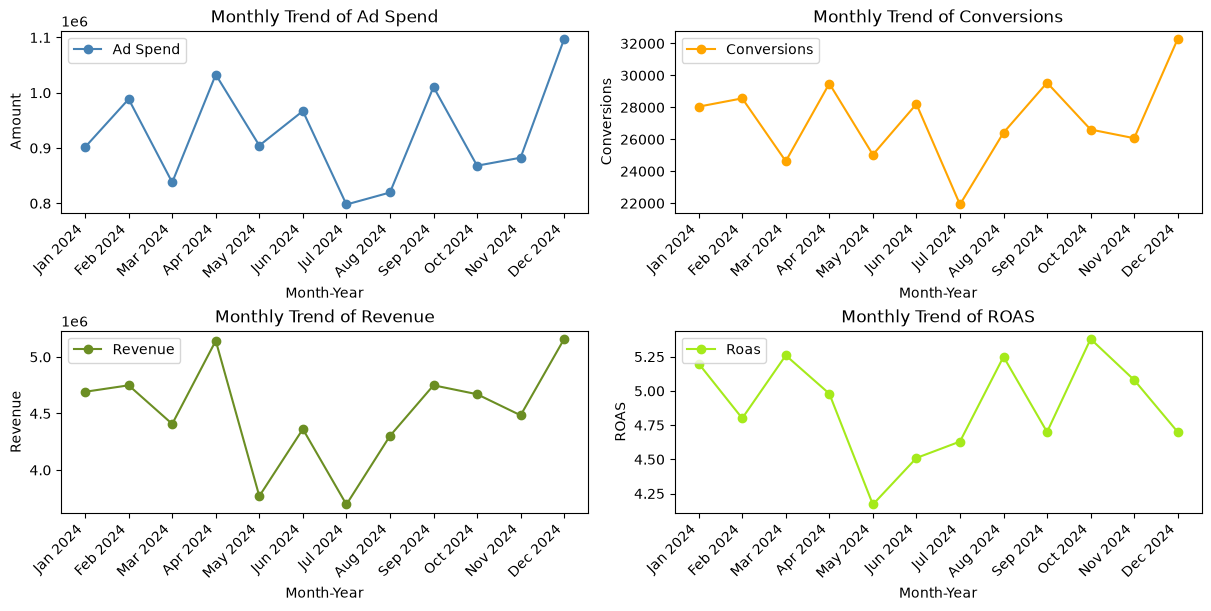

In [34]:
# use matplotlib subplots to visualize monthly trend of spend, revenue, and conversions with dual y-axis for spend and revenue, and a secondary y-axis for conversions
# two plots in one row, with the first plot showing spend and revenue, and the second plot showing conversions
fig, axs = plt.subplots(2, 2, figsize=(12, 6), layout='constrained')
ax1 = axs[0, 0]
ax2 = axs[0, 1]
ax3 = axs[1, 0]
ax4 = axs[1, 1]

ax1.plot(monthly_trend_df['month_year'], monthly_trend_df['spend'], color='steelblue', marker='o', label='Ad Spend')
ax1.set_title('Monthly Trend of Ad Spend')
ax1.set_xlabel('Month-Year')
ax1.set_ylabel('Amount')
ax1.legend()


ax2.plot(monthly_trend_df['month_year'], monthly_trend_df['conversions'], color='orange', marker='o', label='Conversions')
ax2.set_title('Monthly Trend of Conversions')
ax2.set_xlabel('Month-Year')
ax2.set_ylabel('Conversions')
ax2.legend()

ax3.plot(monthly_trend_df['month_year'], monthly_trend_df['revenue'], color="#6B8E23", marker='o', label='Revenue')
ax3.set_xlabel('Month-Year')
ax3.set_title('Monthly Trend of Revenue')
ax3.set_ylabel('Revenue')
ax3.legend()

ax4.plot(monthly_trend_df['month_year'], monthly_trend_df['roas'], color="#A5EA1B", marker='o', label='Roas')
ax4.set_title('Monthly Trend of ROAS')
ax4.set_xlabel('Month-Year')
ax4.set_ylabel('ROAS')
ax4.legend()

# rotate x-axis labels for all subplots
for ax in axs.flat:
    ax.set_xticklabels(monthly_trend_df['month_year'], rotation=45, ha='right') 
plt.show()  

In [35]:
# plot revenue share vs spend share by month-year
fig = go.Figure(data=[
    go.Bar(name='Spend Share', x=monthly_trend_df['month_year'], y=monthly_trend_df['spend_share']),
    go.Bar(name='Revenue Share', x= monthly_trend_df['month_year'], y=monthly_trend_df['revenue_share'])
])
fig.update_layout(barmode='group', title='Budget Share vs Revenue Share by Month-Year', 
                  xaxis_title='Month-Year', 
                  yaxis_title='Share (%)')
#display the number values on top of the bars
fig.update_traces(texttemplate='%{y:.2s%}', textposition='outside')
fig.show()  

## Month-over-month changes

- This identifies periods where spend increased but efficiency deteriorated, which is much more actionable than simply plotting ROAS.

In [36]:
# month-over-month changes in key metrics: spend, revenue, conversions, cpa, roas

monthly_changes_df = run_query("""
    WITH monthly AS (
        SELECT
            DATE_TRUNC('month', date)::date AS month,
            SUM(ad_spend) AS spend,
            SUM(revenue) AS revenue,
            SUM(conversions) AS conversions
            
        FROM "ads-data"
        GROUP BY 1
    ),

    kpi AS (
        SELECT
            *,
            spend / NULLIF(conversions, 0) AS cpa,
            revenue / NULLIF(spend, 0) AS roas
        FROM monthly
    )
    SELECT
        month,
        spend,
        revenue,
        conversions,
        cpa,
        roas,

        LAG(spend) OVER (ORDER BY month) AS prev_spend,
        LAG(revenue) OVER (ORDER BY month) AS prev_revenue,
        LAG(conversions) OVER (ORDER BY month) AS prev_conversions,
        LAG(cpa) OVER (ORDER BY month) AS prev_cpa,
        LAG(roas) OVER (ORDER BY month) AS prev_roas,
        ROUND(
            100.0 * (
                (spend::numeric) / NULLIF(LAG(spend) OVER (ORDER BY month)::numeric, 0) - 1), 2
            ) AS spend_mom_pct,

        ROUND(
            100.0 * ((revenue::numeric / NULLIF(LAG(revenue) OVER (ORDER BY month)::numeric, 0)) - 1
                ), 2) AS revenue_mom_pct,

        ROUND(
            100.0 * (
                (roas::numeric) / NULLIF(LAG(roas) OVER (ORDER BY month)::numeric, 0) - 1
                ), 2) AS roas_mom_pct
    FROM kpi
    ORDER BY month;
""")

display(monthly_changes_df)

,month,spend,revenue,conversions,cpa,roas,prev_spend,prev_revenue,prev_conversions,prev_cpa,prev_roas,spend_mom_pct,revenue_mom_pct,roas_mom_pct
0,2024-01-01,901735.0,4691990.0,28045,32.153142,5.20330,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-02-01,988588.0,4749200.0,28563,34.610806,4.80402,901735.0,4691990.0,28045.0,32.153142,5.20330,9.63,1.22,-7.67
2,2024-03-01,837915.0,4407520.0,24628,34.022868,5.26010,988588.0,4749200.0,28563.0,34.610806,4.80402,-15.24,-7.19,9.49
3,2024-04-01,1032900.0,5143460.0,29490,35.025292,4.97965,837915.0,4407520.0,24628.0,34.022868,5.26010,23.27,16.70,-5.33
4,2024-05-01,904564.0,3768910.0,25037,36.129089,4.16655,1032900.0,5143460.0,29490.0,35.025292,4.97965,-12.42,-26.72,-16.33
5,2024-06-01,966953.0,4362180.0,28207,34.280600,4.51126,904564.0,3768910.0,25037.0,36.129089,4.16655,6.90,15.74,8.27
6,2024-07-01,797918.0,3695090.0,21920,36.401371,4.63092,966953.0,4362180.0,28207.0,34.280600,4.51126,-17.48,-15.29,2.65
7,2024-08-01,819622.0,4301660.0,26415,31.028653,5.24835,797918.0,3695090.0,21920.0,36.401371,4.63092,2.72,16.42,13.33
8,2024-09-01,1010520.0,4749430.0,29543,34.205154,4.69997,819622.0,4301660.0,26415.0,31.028653,5.24835,23.29,10.41,-10.45
9,2024-10-01,868099.0,4670520.0,26612,32.620596,5.38017,1010520.0,4749430.0,29543.0,34.205154,4.69997,-14.09,-1.66,14.47


I created month over month change for *ad spend, revenue, and roas* but one can do this for all other metrics depending on which KPI is being looked at or rather to compare and track the changes in KPIs

## Funnel diagnosis

### Diagnostic e.g: 

- why a platform has a particular CPA?
- why did campaigns perform differently?

In [37]:
# diagnose why a platform has a particular CPA
diagnose_platform_cpa = run_query("""
    WITH platform_performance AS (
        SELECT
            platform,
            SUM(ad_spend) AS spend,
            SUM(conversions) AS conversions,
            SUM(ad_spend) / NULLIF(SUM(conversions), 0) AS cpa
        FROM "ads-data"
        GROUP BY platform
    ),
    campaign_performance AS (
        SELECT
            platform,
            campaign_type,
            SUM(ad_spend) AS spend,
            SUM(conversions) AS conversions,
            SUM(ad_spend) / NULLIF(SUM(conversions), 0) AS cpa
        FROM "ads-data"
        GROUP BY 1, campaign_type
    )
    SELECT
        p.platform,
        p.spend AS platform_spend,
        p.conversions AS platform_conversions,
        p.cpa AS platform_cpa,
        c.campaign_type,
        c.spend AS campaign_spend,
        c.conversions AS campaign_conversions,
        c.cpa AS campaign_cpa,
        ROUND(
            100.0 * (c.spend::numeric / NULLIF(p.spend::numeric, 0)), 2
        ) AS spend_share,
        ROUND(
            100.0 * (c.conversions::numeric / NULLIF(p.conversions::numeric, 0)), 2
        ) AS conversions_share
    FROM platform_performance p
    JOIN campaign_performance c ON p.platform = c.platform
    ORDER BY p.platform, c.cpa DESC;
""")

display(diagnose_platform_cpa)

,platform,platform_spend,platform_conversions,platform_cpa,campaign_type,campaign_spend,campaign_conversions,campaign_cpa,spend_share,conversions_share
0,Google Ads,6349270.0,131098,48.431483,Shopping,1574540.0,30419,51.761785,24.80,23.20
1,Google Ads,6349270.0,131098,48.431483,Display,1481150.0,29301,50.549550,23.33,22.35
2,Google Ads,6349270.0,131098,48.431483,Video,1664050.0,34551,48.162112,26.21,26.36
3,Google Ads,6349270.0,131098,48.431483,Search,1629530.0,36827,44.248126,25.66,28.09
4,Meta Ads,2106060.0,73262,28.746997,Video,535580.0,17162,31.207322,25.43,23.43
5,Meta Ads,2106060.0,73262,28.746997,Display,547626.0,18634,29.388517,26.00,25.43
6,Meta Ads,2106060.0,73262,28.746997,Search,520979.0,18339,28.408266,24.74,25.03
7,Meta Ads,2106060.0,73262,28.746997,Shopping,501877.0,19127,26.239169,23.83,26.11
8,TikTok Ads,2653420.0,122452,21.669052,Shopping,723130.0,30528,23.687439,27.25,24.93
9,TikTok Ads,2653420.0,122452,21.669052,Video,596830.0,27515,21.691064,22.49,22.47


In [38]:
diagnose_platform_cpa = run_query("""
    SELECT
        platform,
        ROUND(
            100.0 * SUM(clicks)
            / NULLIF(SUM(impressions), 0),
            2
        ) AS ctr_pct,

        ROUND(
            (SUM(ad_spend)::numeric
            / NULLIF(SUM(clicks), 0)),
            2
        ) AS cpc,

        ROUND(
            100.0 * (SUM(conversions)::numeric
            / NULLIF(SUM(clicks), 0)),
            2
        ) AS conversion_rate,

        ROUND(
            (SUM(ad_spend)::numeric
            / NULLIF(SUM(conversions), 0)),
            2
        ) AS cpa,

        ROUND(
            (SUM(revenue::numeric)
            / NULLIF(SUM(conversions::numeric), 0)),
            2
        ) AS "revenue_per_conversion"

    FROM "ads-data"

    GROUP BY 1
    ORDER BY 4 DESC;
""")

display(diagnose_platform_cpa)

,platform,ctr_pct,cpc,conversion_rate,cpa,revenue_per_conversion
0,TikTok Ads,5.53,1.02,4.71,21.67,165.15
1,Meta Ads,2.48,1.32,4.59,28.75,162.79
2,Google Ads,3.98,2.16,4.46,48.43,168.07


## Build a Decision Table

Now the KPIs exist, create a management classification...this is basically simulation because I do not have business rules, so I am using an example here.

For example, suppose the business defines:

- minimum ROAS = 5
- maximum CPA = $30
- minimum spend = $10,000

then:

In [39]:
# build a performance status table with the following logic:

decision_df = run_query("""
    WITH performance AS (
        SELECT
            platform,
            campaign_type,
            country,

            SUM(ad_spend) AS spend,
            SUM(revenue) AS revenue,
            SUM(conversions) AS conversions

        FROM "ads-data"
        GROUP BY 1, 2, 3
    ),

    kpi AS (

        SELECT
            *,
            spend / NULLIF(conversions, 0) AS cpa,
            revenue / NULLIF(spend, 0) AS roas
        FROM performance
    )

    SELECT
        *,
        CASE WHEN spend < 10000
                THEN 'Insufficient scale'

            WHEN roas >= 5 AND cpa <= 30
                THEN 'Meets target'

            WHEN roas >= 5 AND cpa > 30
                THEN 'CPA issue'

            WHEN roas < 5 AND cpa <= 30
                THEN 'ROAS issue'

            ELSE 'Below target'
        END AS performance_status

    FROM kpi
    ORDER BY roas DESC;
""")

display(decision_df.head(10))

,platform,campaign_type,country,spend,revenue,conversions,cpa,roas,performance_status
0,TikTok Ads,Search,Australia,71559.5,1220030.0,6004,11.918641,17.04920,Meets target
1,TikTok Ads,Video,Canada,75347.2,764236.0,4502,16.736376,10.14290,Meets target
2,TikTok Ads,Display,UK,105858.0,1063580.0,5337,19.834733,10.04730,Meets target
3,TikTok Ads,Video,Germany,70406.0,673651.0,3675,19.158102,9.56808,Meets target
4,TikTok Ads,Display,Canada,92289.0,853477.0,4497,20.522338,9.24788,Meets target
5,TikTok Ads,Display,UAE,54390.9,474015.0,2757,19.728307,8.71497,Meets target
6,TikTok Ads,Search,India,115553.0,997472.0,5244,22.035326,8.63214,Meets target
7,TikTok Ads,Video,USA,76474.8,650727.0,3600,21.243006,8.50904,Meets target
8,TikTok Ads,Search,Canada,137529.0,1090640.0,6947,19.796895,7.93023,Meets target
9,Meta Ads,Video,Germany,81094.2,631837.0,3092,26.227088,7.79140,Meets target


In [40]:
display(decision_df.tail(10))

,platform,campaign_type,country,spend,revenue,conversions,cpa,roas,performance_status
74,Google Ads,Video,Germany,149094.0,468343.0,2776,53.708106,3.14126,Below target
75,Google Ads,Video,UAE,273380.0,834848.0,4440,61.571966,3.05381,Below target
76,Google Ads,Display,Canada,291796.0,877016.0,5145,56.714577,3.00557,Below target
77,Google Ads,Search,UK,253004.0,738157.0,4737,53.410231,2.91757,Below target
78,Google Ads,Video,USA,304055.0,883963.0,6618,45.943577,2.90725,Below target
79,Google Ads,Shopping,Canada,257549.0,724426.0,3771,68.297381,2.81277,Below target
80,Google Ads,Shopping,Germany,247097.0,677605.0,4716,52.395389,2.74227,Below target
81,Google Ads,Display,India,177497.0,465925.0,3273,54.230799,2.62497,Below target
82,Google Ads,Shopping,USA,225319.0,520357.0,3795,59.372579,2.30942,Below target
83,Google Ads,Display,USA,186434.0,424199.0,3305,56.409834,2.27532,Below target


The thresholds here are illustrative; they should come from the company's economics.